In [1]:
from google.colab import drive
#Loading the drive place where I can find my folders
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# ============================================================
# Biomass prediction
# ------------------------------------------------------------
# The goal of this notebook:
# This notebook trains a multimodal deep learning model to
# predict biomass-related targets by combining:
#   1) image features from a ResNet50 CNN,
#   2) tabular metadata features,
#   3) a one-hot encoding of which biomass target is being predicted.
#
# Final architecture:
# ResNet50 CNN + tabular NN + target one-hot encoding
# -> concatenation -> MLP fusion head -> final scalar prediction.
#
# Important implementation details:
# - The train/validation split is leakage-safe because it is done
#   by unique image_path rather than by row.
# - Hyperparameter tuning is performed using both random search
#   and grid search.
# - Targets and numeric features are scaled using statistics from
#   the training split only, to avoid data leakage.
# ============================================================

import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Seed setting
# ----------------------------

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seeds(42)
USE_AMP= torch.cuda.is_available()
SEED=42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Paths
# Note: might differ for each person executing this notebook!
# ----------------------------
BASE_DIR = "/content/drive/My Drive/DL_Data/split_blanche/"
TRAIN_CSV = os.path.join(BASE_DIR, "train_split.csv")   # full train file
TEST_CSV  = os.path.join(BASE_DIR, "test_split.csv")    # test file, to do final evaluation
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test_images")

# These are the five biomass-related targets in the dataset
TARGET_NAMES = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]

# Custom weights used when computing weighted R^2
#Higher weight means that target contributes more to the final score
TARGET_WEIGHTS = {
    "Dry_Total_g": 0.4,
    "GDM_g": 0.2,
    "Dry_Green_g": 0.2,
    "Dry_Dead_g": 0.1,
    "Dry_Clover_g": 0.1,
}

# Numeric and categorical tabular features used alongside the image
NUMERIC_COLS = ["Pre_GSHH_NDVI", "Height_Ave_cm"]
CATEGORICAL_COLS = ["State", "Species"]

# Makes recreation for CNN only easier, if needed(not now)
USE_TABULAR = True

In [3]:
# ----------------------------
# Leakage-safe split
# ----------------------------
# The dataset has multiple rows per image (one row per target)
# To avoid leakage, the split is performed on unique image_path values,
# not diretly on rows. This guarantees that the same image cannot appear
# in both training and validation set

def split_by_image_path(df, val_size=0.2, random_state=42):
    unique_images = df["image_path"].unique()

    train_imgs, val_imgs = train_test_split(
        unique_images,
        test_size=val_size,
        random_state=random_state,
        shuffle=True
    )

    train_imgs = set(train_imgs)
    val_imgs = set(val_imgs)

    train_df = df[df["image_path"].isin(train_imgs)].reset_index(drop=True)
    val_df = df[df["image_path"].isin(val_imgs)].reset_index(drop=True)

    # Safety checks:
    # 1) no image can appear in both splits
    # 2) each image should still have 5 rows (one for each target)
    assert len(set(train_df["image_path"]) & set(val_df["image_path"])) == 0, "Leakage detected!"
    assert (train_df.groupby("image_path").size() == 5).all(), "Train split broke 5-target grouping."
    assert (val_df.groupby("image_path").size() == 5).all(), "Val split broke 5-target grouping."

    return train_df, val_df

# ----------------------------
# Tabular preprocessing
# Fit on TRAIN only
# ----------------------------
# This function builds tabular input matrices for train/val/test
#
# Processing steps:
# - categorical columns are one-hot encoded,
# - numeric columns are standardized,
# - all transformers are fitted on the training set only
#
# This avoids leakage from validation/test data

def build_tabular_features(train_df, val_df, test_df=None, use_tabular=True):
    if not use_tabular:
      # If tabular are disabled, return a dummy feature vector
      # This keeps the model its interface consistent
        train_tab = np.zeros((len(train_df), 1), dtype=np.float32)
        val_tab = np.zeros((len(val_df), 1), dtype=np.float32)
        test_tab = None if test_df is None else np.zeros((len(test_df), 1), dtype=np.float32)
        return train_tab, val_tab, test_tab, ["dummy"]

    # One-hot encode categorical variables separatly for each split.
    train_cat = pd.get_dummies(train_df[CATEGORICAL_COLS], columns=CATEGORICAL_COLS)
    val_cat = pd.get_dummies(val_df[CATEGORICAL_COLS], columns=CATEGORICAL_COLS)

    if test_df is not None:
        test_cat = pd.get_dummies(test_df[CATEGORICAL_COLS], columns=CATEGORICAL_COLS)
    else:
        test_cat = None

    # Align validation/test columns to training columns
    # This is necessary because some categories may not exist in val/test
    val_cat = val_cat.reindex(columns=train_cat.columns, fill_value=0)
    if test_cat is not None:
        test_cat = test_cat.reindex(columns=train_cat.columns, fill_value=0)

    # Standardize numeric features using training statistics only
    scaler = StandardScaler()
    train_num = scaler.fit_transform(train_df[NUMERIC_COLS].astype(np.float32))
    val_num = scaler.transform(val_df[NUMERIC_COLS].astype(np.float32))
    test_num = scaler.transform(test_df[NUMERIC_COLS].astype(np.float32)) if test_df is not None else None

    # Combine standardized numeric features and one-hot categorical features
    train_tab_df = pd.concat(
        [
            pd.DataFrame(train_num, columns=NUMERIC_COLS, index=train_df.index),
            train_cat.reset_index(drop=True),
        ],
        axis=1,
    )

    val_tab_df = pd.concat(
        [
            pd.DataFrame(val_num, columns=NUMERIC_COLS, index=val_df.index),
            val_cat.reset_index(drop=True),
        ],
        axis=1,
    )

    if test_df is not None:
        test_tab_df = pd.concat(
            [
                pd.DataFrame(test_num, columns=NUMERIC_COLS, index=test_df.index),
                test_cat.reset_index(drop=True),
            ],
            axis=1,
        )
    else:
        test_tab_df = None

    return (
        train_tab_df.astype(np.float32).to_numpy(),
        val_tab_df.astype(np.float32).to_numpy(),
        None if test_tab_df is None else test_tab_df.astype(np.float32).to_numpy(),
        list(train_tab_df.columns),
    )


# ----------------------------
# Target scaling
# Fit on TRAIN only, ensuring leakage-safety
# ----------------------------
# The target variable is standardized before training
# This often stabilizes optimization for regression models
#
# Again, the scalar is fitted on the training split only

def build_target_scaler(train_df, val_df, test_df=None):
    scaler = StandardScaler()

    train_y = scaler.fit_transform(train_df[["target"]].astype(np.float32)).reshape(-1)
    val_y = scaler.transform(val_df[["target"]].astype(np.float32)).reshape(-1)

    if test_df is not None:
        test_y = scaler.transform(test_df[["target"]].astype(np.float32)).reshape(-1)
    else:
        test_y = None

    return train_y.astype(np.float32), val_y.astype(np.float32), test_y, scaler

# ----------------------------
# Weighted R²
# IMPORTANT:
# use original-scale predictions and targets here
# ----------------------------
# This custom metric computes a weighted r^2 across the five targets
#
# Why use this?
# - standard R^2 would treat all rows equally,
# - here, some target types are considered more important,
#   so they receive larger weights

def weighted_r2(all_preds: np.ndarray, all_targets: np.ndarray, all_names: np.ndarray) -> float:
    df = pd.DataFrame({
        "pred": all_preds,
        "target": all_targets,
        "target_name": all_names
    })

    ssres_total = 0.0
    sstot_total = 0.0

    for target_name, weight in TARGET_WEIGHTS.items():
        subset = df[df["target_name"] == target_name]
        if len(subset) == 0:
            continue

        # Residual sum of squares
        ssres = ((subset["target"] - subset["pred"]) ** 2).sum()

        # Total sum of squares
        sstot = ((subset["target"] - subset["target"].mean()) ** 2).sum()

        ssres_total += weight * ssres
        sstot_total += weight * sstot

    # Edge case: if variance is zero, retunr a sensible value
    if sstot_total == 0:
        return 1.0 if ssres_total == 0 else 0.0

    return 1.0 - (ssres_total / sstot_total)


# ----------------------------
# Dataset
# ----------------------------
# Custom PyTorch Dataset for loading:
# - image,
# - tabular features,
# - one-hot encoded target type,
# - scaled regression target

class BiomassDataset(Dataset):
    def __init__(self, df, img_dir, tabular_array, y_array, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform
        self.tabular_array = tabular_array
        self.y_array = y_array

        # Build mapping from target name to integer index
        self.target_to_idx = {name: i for i, name in enumerate(TARGET_NAMES)}
        target_idx = self.df["target_name"].map(self.target_to_idx).values

        # Convert target name into one-hot vector
        # This tells the model which biomass target is should predict
        self.target_oh = np.eye(len(TARGET_NAMES), dtype=np.float32)[target_idx]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # image_path may contain a prefix, so only the actual file name is used
        img_name = row["image_path"].split("/", 1)[-1]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        x_tab = torch.tensor(self.tabular_array[idx], dtype=torch.float32)
        target_oh = torch.tensor(self.target_oh[idx], dtype=torch.float32)
        y = torch.tensor(self.y_array[idx], dtype=torch.float32)

        return {
            "image": image,
            "tabular": x_tab,
            "target_oh": target_oh,
            "target": y,
            "target_name": row["target_name"],
            "image_path": row["image_path"],
        }


# ----------------------------
# Weight initialization helpers
# Only initialize NEW layers
# Do NOT reinitialize pretrained ResNet backbone
# ----------------------------
# Since the ResNet backbone is pretrained, only the newly added linear
# layers are initialized manually. Different initialization schemes can
# be explored during hyperparameter search

def init_linear_weights(module, init_name="kaiming"):
    if isinstance(module, nn.Linear):
        if init_name == "kaiming":
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        elif init_name == "xavier":
            nn.init.xavier_normal_(module.weight)
        elif init_name == "normal":
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif init_name == "orthogonal":
            nn.init.orthogonal_(module.weight)
        else:
            raise ValueError(f"Unknown init_name: {init_name}")

        if module.bias is not None:
            nn.init.zeros_(module.bias)


# ----------------------------
# Model
# ----------------------------
# This model fuses three sources of information:
# 1) image features from ResNet50,
# 2) tabular features from a small MLP,
# 3) one-hot encoded target identity
#
# The output is a single scalar regression value

class ResNet50TabularFusion(nn.Module):
    def __init__(
        self,
        tabular_dim,
        img_feat_dim=256,
        tab_hidden=(128, 64),
        fusion_hidden=(256, 128),
        dropout=0.2,
        freeze_backbone=False,
        init_name="kaiming",
    ):
        super().__init__()

        # Load pretrained ResNet50 and remove its final classification layer
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Optional: freeze CNN backbone during training
        # This can be useful if the dataset is small or to reduce overfitting
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Project ResNet output into a lower-dimensional image feature space
        self.image_proj = nn.Sequential(
            nn.Linear(in_features, img_feat_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Small MLP for tabular inputs
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(tab_hidden[0], tab_hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Fusion input combines:
        # image features + tabular features + target one-hot vector
        fusion_in = img_feat_dim + tab_hidden[1] + len(TARGET_NAMES)

        # Final MLP head for regression
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_in, fusion_hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden[0], fusion_hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden[1], 1),
        )

        # initialize only newly added layers
        self.image_proj.apply(lambda m: init_linear_weights(m, init_name))
        self.tabular_net.apply(lambda m: init_linear_weights(m, init_name))
        self.fusion_head.apply(lambda m: init_linear_weights(m, init_name))

    def forward(self, image, tabular, target_oh):
        # Extract image embedding from pretrained CNN
        img_feat = self.backbone(image)
        img_feat = self.image_proj(img_feat)

        # Extract tabular embedding
        tab_feat = self.tabular_net(tabular)

        # Concatenate all feature sources
        fused = torch.cat([img_feat, tab_feat, target_oh], dim=1)

        #Output a single regression value
        out = self.fusion_head(fused).squeeze(1)
        return out


# ----------------------------
# Transforms
# ----------------------------
# These transforms convert images to tensors and normalize them
# The mean and std values appear to be precomputed from this dataset

def get_transforms():
    mean = [0.43918201, 0.49828457, 0.30579902]
    std = [0.24945421, 0.24771695, 0.23592069]

    train_tfms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_tfms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return train_tfms, eval_tfms


# ----------------------------
# DataLoader helper
# ----------------------------
# This function builds PyTorch DataLoaders for training and validation
# num_workers is capped to avoid over-using CPU resources

def make_loaders(train_ds, val_ds, batch_size=32):
    cpu_count = os.cpu_count() if os.cpu_count() is not None else 0
    num_workers = min(4, cpu_count)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        num_workers=num_workers,
        persistent_workers=(num_workers > 0),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
        num_workers=num_workers,
        persistent_workers=(num_workers > 0),
    )

    return train_loader, val_loader


# ----------------------------
# Train / Eval
# ----------------------------
# One full training epoch

def train_one_epoch(model, loader, optimizer, criterion, grad_scaler):
    model.train()
    running_loss = 0.0

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        tabular = batch["tabular"].to(DEVICE, non_blocking=True)
        target_oh = batch["target_oh"].to(DEVICE, non_blocking=True)
        y = batch["target"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass when running GPU
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            preds = model(images, tabular, target_oh)
            loss = criterion(preds, y)

        # Gradient scaling improves stability in mixed precision training
        grad_scaler.scale(loss).backward()
        grad_scaler.step(optimizer)
        grad_scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

# Validation/Evaluation loop
# Returns validation MSE, weighted R^2, and predictions/targets in original scale
@torch.no_grad()
def evaluate(model, loader, criterion, target_scaler):
    model.eval()
    running_loss = 0.0

    all_preds_scaled = []
    all_targets_scaled = []
    all_names = []

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        tabular = batch["tabular"].to(DEVICE, non_blocking=True)
        target_oh = batch["target_oh"].to(DEVICE, non_blocking=True)
        y = batch["target"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            preds = model(images, tabular, target_oh)
            loss = criterion(preds, y)

        running_loss += loss.item() * images.size(0)

        all_preds_scaled.extend(preds.detach().cpu().numpy())
        all_targets_scaled.extend(y.detach().cpu().numpy())
        all_names.extend(batch["target_name"])

    mean_mse = running_loss / len(loader.dataset)

    # Convert predictions and targets back to original scale
    # Weighted R^2 should be computed in the original unit space

    all_preds_scaled = np.array(all_preds_scaled).reshape(-1, 1)
    all_targets_scaled = np.array(all_targets_scaled).reshape(-1, 1)

    preds_orig = target_scaler.inverse_transform(all_preds_scaled).reshape(-1)
    targets_orig = target_scaler.inverse_transform(all_targets_scaled).reshape(-1)

    val_r2 = weighted_r2(preds_orig, targets_orig, np.array(all_names))

    return mean_mse, val_r2, preds_orig, targets_orig, np.array(all_names)

# Full training routine with early stopping and LR scheduling
def fit_model(
    model,
    train_loader,
    val_loader,
    target_scaler,
    lr=1e-4,
    weight_decay=1e-4,
    epochs=12,
    patience=3
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )
    # Reduce learning rate when validation MSE stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )

    grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_mse = float("inf")
    best_val_r2 = -float("inf")
    best_state = None
    best_epoch = -1
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, grad_scaler)
        val_mse, val_r2, _, _, _ = evaluate(model, val_loader, criterion, target_scaler)

        scheduler.step(val_mse)

        history.append({
            "epoch": epoch,
            "train_mse": train_loss,
            "val_mse": val_mse,
            "val_r2": val_r2,
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_mse={train_loss:.6f} | "
            f"val_mse={val_mse:.6f} | "
            f"val_r2={val_r2:.5f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        # Early stopping based on MSE
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_val_r2 = val_r2
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break
    # Restore best checkpoint before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val_mse, best_val_r2, best_epoch, pd.DataFrame(history)


# ----------------------------
# Build model from params
# ----------------------------
# Helper function used during baseline training and hyperparameter search
def make_model_from_params(params, tabular_dim):
    return ResNet50TabularFusion(
        tabular_dim=tabular_dim,
        img_feat_dim=params["img_feat_dim"],
        tab_hidden=params["tab_hidden"],
        fusion_hidden=params["fusion_hidden"],
        dropout=params["dropout"],
        freeze_backbone=params["freeze_backbone"],
        init_name=params["init_name"],
    ).to(DEVICE)


# ----------------------------
# One trial
# ----------------------------
# A trial means:
# - create datasets and loaders,
# - build the model from a parameter set,
# - train and validate,
# - return both metrics and model weights

def run_trial(params, train_df, val_df, train_tab, val_tab, train_y, val_y, target_scaler):
    set_seeds(params["seed"])

    train_tfms, val_tfms = get_transforms()

    train_ds = BiomassDataset(train_df, TRAIN_IMG_DIR, train_tab, train_y, transform=train_tfms)
    val_ds   = BiomassDataset(val_df, TRAIN_IMG_DIR, val_tab, val_y, transform=val_tfms)

    train_loader, val_loader = make_loaders(
        train_ds,
        val_ds,
        batch_size=params["batch_size"]
    )

    model = make_model_from_params(params, tabular_dim=train_tab.shape[1])

    model, best_val_mse, best_val_r2, best_epoch, history_df = fit_model(
        model,
        train_loader,
        val_loader,
        target_scaler=target_scaler,
        lr=params["lr"],
        weight_decay=params["weight_decay"],
        epochs=params["epochs"],
        patience=params["patience"],
    )

    return {
        "params": params,
        "best_val_mse": best_val_mse,
        "best_val_r2": best_val_r2,
        "best_epoch": best_epoch,
        "history": history_df,
        "state_dict": copy.deepcopy(model.state_dict()),
    }

# Random search explores a random subset of all possible combinations
# This could be more efficient than full grid search when the search space is large
def random_search(train_df, val_df, train_tab, val_tab, train_y, val_y, target_scaler, n_trials=10):
    search_space = {
        "seed": [42],
        "init_name": ["kaiming", "xavier", "normal", "orthogonal"],
        "lr": [3e-5, 1e-4, 3e-4],
        "weight_decay": [1e-5, 1e-4],
        "epochs": [10, 15, 20],
        "patience": [3],
        "batch_size": [32, 64],
        "img_feat_dim": [128, 256],
        "tab_hidden": [(64, 32), (128, 64)],
        "fusion_hidden": [(128, 64), (256, 128)],
        "dropout": [0.1, 0.2, 0.3],
        "freeze_backbone": [False, True],
    }

    # build all possible combinations, then sample from it
    keys = list(search_space.keys())
    values = list(search_space.values())
    all_combos = [dict(zip(keys, combo)) for combo in itertools.product(*values)]

    total_combos = len(all_combos)
    print(f"Total possible random-search combinations: {total_combos}")

    if n_trials > total_combos:
        print(f"Requested n_trials={n_trials}, but only {total_combos} unique combinations exist.")
        n_trials = total_combos

    # sample without replacement to avoid testing the same combination twice
    sampled_combos = random.sample(all_combos, n_trials)

    results = []
    best = None

    for trial, params in enumerate(sampled_combos, start=1):
        print(f"\n===== Random trial {trial}/{n_trials} =====")
        print(params)

        result = run_trial(
            params,
            train_df, val_df,
            train_tab, val_tab,
            train_y, val_y,
            target_scaler
        )
        results.append(result)

        if (best is None) or (result["best_val_mse"] < best["best_val_mse"]):
            best = result
            print("New best val MSE:", best["best_val_mse"], "| val R²:", best["best_val_r2"])

    # Build a clean summary table for easier comparison
    summary = pd.DataFrame([
        {
            **r["params"],
            "best_val_mse": r["best_val_mse"],
            "best_val_r2": r["best_val_r2"],
            "best_epoch": r["best_epoch"],
        }
        for r in results
    ]).sort_values("best_val_mse", ascending=True).reset_index(drop=True)

    return best, summary, results

# ----------------------------
# Grid Search
# ----------------------------
# Grid search tries every combination in a smaller, self-selected search grid
# Compared to random search, it is more computational costly
def grid_search(train_df, val_df, train_tab, val_tab, train_y, val_y, target_scaler):
    grid = {
        "seed": [42],
        "init_name": ["kaiming", "xavier"],
        "lr": [1e-4, 3e-4],
        "weight_decay": [1e-4],
        "epochs": [10, 15],
        "patience": [3],
        "batch_size": [32],
        "img_feat_dim": [256],
        "tab_hidden": [(128, 64)],
        "fusion_hidden": [(128, 64), (256, 128)],
        "dropout": [0.1, 0.2],
        "freeze_backbone": [False],
    }

    keys = list(grid.keys())
    values = list(grid.values())
    combos = list(itertools.product(*values))

    print(f"Total grid combinations: {len(combos)}")

    results = []
    best = None

    for i, combo in enumerate(combos, start=1):
        params = dict(zip(keys, combo))
        print(f"\n===== Grid trial {i}/{len(combos)} =====")
        print(params)

        result = run_trial(
            params,
            train_df, val_df,
            train_tab, val_tab,
            train_y, val_y,
            target_scaler
        )
        results.append(result)

        if (best is None) or (result["best_val_mse"] < best["best_val_mse"]):
            best = result
            print("New best val MSE:", best["best_val_mse"], "| val R²:", best["best_val_r2"])

    summary = pd.DataFrame([
        {
            **r["params"],
            "best_val_mse": r["best_val_mse"],
            "best_val_r2": r["best_val_r2"],
            "best_epoch": r["best_epoch"],
        }
        for r in results
    ]).sort_values("best_val_mse", ascending=True).reset_index(drop=True)

    return best, summary, results




In [4]:
# ----------------------------
# Main
# ----------------------------
# Load the full training CSV and create the train/validation split
split_seed = SEED
set_seeds(split_seed)

full_df = pd.read_csv(TRAIN_CSV)

# leakage-safe split
train_df, val_df = split_by_image_path(
    full_df,
    val_size=0.2,
    random_state=split_seed
)

# tabular preprocessing fit on TRAIN only
train_tab, val_tab, _, tab_cols = build_tabular_features(
    train_df, val_df, test_df=None, use_tabular=USE_TABULAR
)

# target scaling fit on TRAIN only
train_y, val_y, _, target_scaler = build_target_scaler(
    train_df, val_df, test_df=None
)

print("DEVICE:", DEVICE)
print("AMP enabled:", USE_AMP)
print("Unique train images:", train_df["image_path"].nunique())
print("Unique val images:", val_df["image_path"].nunique())
print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Tabular dimension:", train_tab.shape[1])




DEVICE: cuda
AMP enabled: True
Unique train images: 456
Unique val images: 114
Train rows: 2280
Val rows: 570
Tabular dimension: 21


In [ ]:
# ----------------------------
# Single baseline run
# ----------------------------
# First, train one reasonable baseline before performing hyperparameter tuning
baseline_params = {
    "seed": 42,
    "init_name": "kaiming",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "epochs": 12,
    "patience": 3,
    "batch_size": 32,
    "img_feat_dim": 256,
    "tab_hidden": (128, 64),
    "fusion_hidden": (256, 128),
    "dropout": 0.2,
    "freeze_backbone": False,
}

print("\n===== Baseline run =====")
print(baseline_params)

baseline_result = run_trial(
    baseline_params,
    train_df, val_df,
    train_tab, val_tab,
    train_y, val_y,
    target_scaler
)

print("\nBaseline best val MSE:", baseline_result["best_val_mse"])
print("Baseline best val R²:", baseline_result["best_val_r2"])
print("Baseline best epoch:", baseline_result["best_epoch"])

# Save baseline training history for later analysis
baseline_result["history"].to_csv("baseline_history.csv", index=False)



===== Baseline run =====
{'seed': 42, 'init_name': 'kaiming', 'lr': 0.0001, 'weight_decay': 0.0001, 'epochs': 12, 'patience': 3, 'batch_size': 32, 'img_feat_dim': 256, 'tab_hidden': (128, 64), 'fusion_hidden': (256, 128), 'dropout': 0.2, 'freeze_backbone': False}


/tmp/ipykernel_1550/2927010871.py:413: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_1550/2927010871.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/2927010871.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01 | train_mse=0.908108 | val_mse=0.803036 | val_r2=0.05728 | lr=1.00e-04


/tmp/ipykernel_1550/2927010871.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/2927010871.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 02 | train_mse=0.755397 | val_mse=0.768606 | val_r2=0.06967 | lr=1.00e-04


...

Epoch 10 | train_mse=0.386075 | val_mse=0.434367 | val_r2=0.52522 | lr=1.00e-04


/tmp/ipykernel_1550/2927010871.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/2927010871.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 11 | train_mse=0.341115 | val_mse=0.411333 | val_r2=0.54221 | lr=1.00e-04


/tmp/ipykernel_1550/2927010871.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/2927010871.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 12 | train_mse=0.324688 | val_mse=0.413611 | val_r2=0.52746 | lr=1.00e-04

Baseline best val MSE: 0.41133278367812176
Baseline best val R²: 0.5422065
Baseline best epoch: 11


In [ ]:
# ----------------------------
# Random search
# ----------------------------
# Explore a wider range of hyperparameters using random sampling
best_random, random_summary, random_results = random_search(
    train_df, val_df,
    train_tab, val_tab,
    train_y, val_y,
    target_scaler,
    n_trials=10
)

print("\nTop random search results:")
print(random_summary.head(10))

random_summary.to_csv("random_search_summary.csv", index=False)



Total possible random-search combinations: 6912

===== Random trial 1/10 =====
{'seed': 42, 'init_name': 'orthogonal', 'lr': 3e-05, 'weight_decay': 1e-05, 'epochs': 10, 'patience': 3, 'batch_size': 64, 'img_feat_dim': 128, 'tab_hidden': (64, 32), 'fusion_hidden': (256, 128), 'dropout': 0.1, 'freeze_backbone': False}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 92.2MB/s]
/tmp/ipykernel_2690/3945598253.py:413: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_2690/3945598253.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_2690/3945598253.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01 | train_mse=0.970301 | val_mse=1.005742 | val_r2=-0.20273 | lr=3.00e-05


/tmp/ipykernel_2690/3945598253.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_2690/3945598253.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 02 | train_mse=0.828846 | val_mse=0.878608 | val_r2=-0.02119 | lr=3.00e-05


...

Epoch 18 | train_mse=0.559263 | val_mse=0.552598 | val_r2=0.34707 | lr=1.00e-04


/tmp/ipykernel_2690/3945598253.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_2690/3945598253.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 19 | train_mse=0.496312 | val_mse=0.524211 | val_r2=0.39630 | lr=1.00e-04


/tmp/ipykernel_2690/3945598253.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_2690/3945598253.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 20 | train_mse=0.493240 | val_mse=0.525867 | val_r2=0.38300 | lr=1.00e-04

Top random search results:
   seed   init_name       lr  weight_decay  epochs  patience  batch_size  \
0    42  orthogonal  0.00010       0.00001      20         3          64   
1    42     kaiming  0.00010       0.00010      20         3          64   
2    42  orthogonal  0.00010       0.00010      10         3          32   
3    42     kaiming  0.00003       0.00001      20         3          32   
4    42     kaiming  0.00010       0.00010      10         3          64   
5    42      xavier  0.00003       0.00010      20         3          32   
6    42     kaiming  0.00010       0.00001      20         3          64   
7    42      xavier  0.00003       0.00001      20         3          64   
8    42      xavier  0.00003       0.00001      15         3          32   
9    42  orthogonal  0.00003       0.00001      10         3          64   

   img_feat_dim tab_hidden fusion_hidden  dropout  free

In [ ]:
# ----------------------------
# Grid search
# ----------------------------
# Exhaustively test all combinations in a smaller, curated search grid
best_grid, grid_summary, grid_results = grid_search(
    train_df, val_df,
    train_tab, val_tab,
    train_y, val_y,
    target_scaler
)

print("\nTop grid search results:")
print(grid_summary.head(10))

grid_summary.to_csv("grid_search_summary.csv", index=False)

# ----------------------------
# Pick best overall by val MSE
# ----------------------------
# Compare the best grid-search model and the best random-search model
if best_grid["best_val_mse"] <= best_random["best_val_mse"]:
    best_overall = best_grid
    best_source = "grid_search"
else:
    best_overall = best_random
    best_source = "random_search"
# Save the final selected model weights
torch.save(best_overall["state_dict"], "best_biomass_fusion_resnet50_mse_weightedr2.pth")



Total grid combinations: 32

===== Grid trial 1/32 =====
{'seed': 42, 'init_name': 'kaiming', 'lr': 0.0001, 'weight_decay': 0.0001, 'epochs': 10, 'patience': 3, 'batch_size': 32, 'img_feat_dim': 256, 'tab_hidden': (128, 64), 'fusion_hidden': (128, 64), 'dropout': 0.1, 'freeze_backbone': False}


/tmp/ipykernel_1550/473127682.py:413: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_1550/473127682.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/473127682.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01 | train_mse=0.818588 | val_mse=0.777177 | val_r2=0.08929 | lr=1.00e-04


/tmp/ipykernel_1550/473127682.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/473127682.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 02 | train_mse=0.660989 | val_mse=0.665032 | val_r2=0.22875 | lr=1.00e-04


...

Epoch 01 | train_mse=0.764410 | val_mse=0.677923 | val_r2=0.24599 | lr=3.00e-04


/tmp/ipykernel_1550/473127682.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1550/473127682.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 02 | train_mse=0.566406 | val_mse=0.599772 | val_r2=0.28034 | lr=3.00e-04


/tmp/ipykernel_1550/473127682.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


KeyboardInterrupt: 

In [ ]:
# -----------------------------
# Model results
# -----------------------------
print("\nSaved best model.")
print("Best source:", best_source)
print("Best validation MSE:", best_overall["best_val_mse"])
print("Best validation weighted R²:", best_overall["best_val_r2"])
print("Best epoch:", best_overall["best_epoch"])
print("Best params:", best_overall["params"])


Saved best model.


NameError: name 'best_source' is not defined

/tmp/ipykernel_536/2378516470.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_536/1295456964.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01 | train_loss=0.742960 | val_loss=0.713952 | val_r2=0.16201 | lr=3.00e-04


/tmp/ipykernel_536/1295456964.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 02 | train_loss=0.502748 | val_loss=0.536168 | val_r2=0.36463 | lr=3.00e-04


/tmp/ipykernel_536/1295456964.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

Epoch 13 | train_loss=0.071020 | val_loss=0.218086 | val_r2=0.73209 | lr=3.00e-04


/tmp/ipykernel_536/1295456964.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 14 | train_loss=0.072021 | val_loss=0.197844 | val_r2=0.75332 | lr=1.50e-04


/tmp/ipykernel_536/1295456964.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 15 | train_loss=0.061745 | val_loss=0.195999 | val_r2=0.75600 | lr=1.50e-04
Early stopping at epoch 15. Best epoch was 12.

===== Final BEST_PARAMS run finished =====
Best epoch: 12
Best validation MSE: 0.1943554885554732
Best validation R²: 0.77031803
BEST_PARAMS: {'seed': 42, 'init_name': 'xavier', 'lr': 0.0003, 'weight_decay': 0.0001, 'epochs': 20, 'patience': 3, 'batch_size': 32, 'img_feat_dim': 256, 'tab_hidden': (128, 64), 'fusion_hidden': (128, 64), 'dropout': 0.1, 'freeze_backbone': False}
Saved best model to: /content/drive/My Drive/DL_Data/split_blanche/best_model_from_best_params.pth


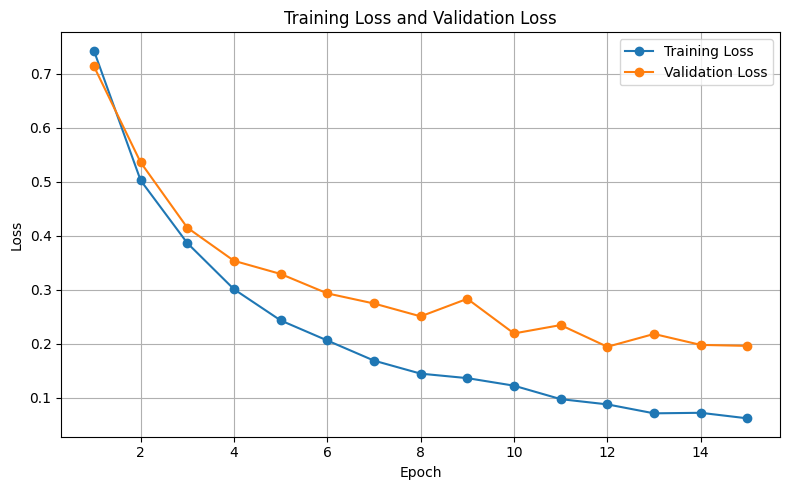

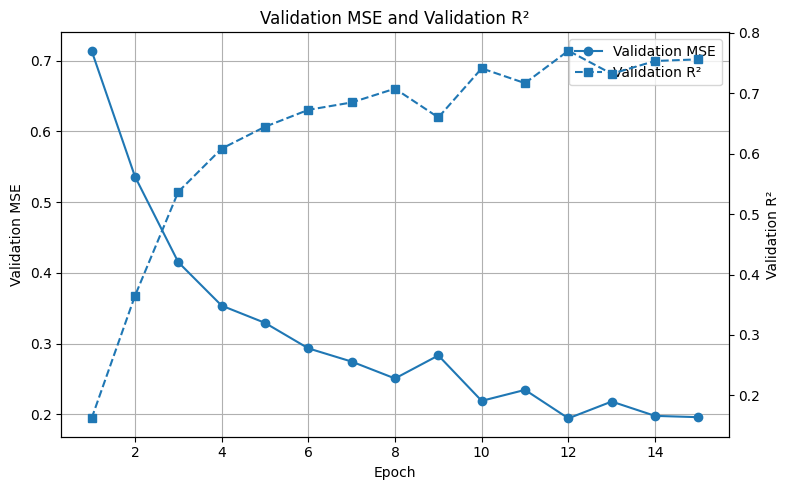

In [10]:
# ============================================================
# Final rerun with BEST_PARAMS + correct combined plots
# ============================================================
# After tuning, the notebook reruns training using the selected best
# hyperparameters and produces cleaner plots for reporting

import copy
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ----------------------------
#  Best parameters config
# ----------------------------
# These are the selected hyperparameters from previous tuning

BEST_PARAMS = {
    "seed": 42,
    "init_name": "xavier",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "epochs": 20,
    "patience": 3,
    "batch_size": 32,
    "img_feat_dim": 256,
    "tab_hidden": (128, 64),
    "fusion_hidden": (128, 64),
    "dropout": 0.1,
    "freeze_backbone": False,
}

# ----------------------------
# Fit model and return history
# ----------------------------
# This version of the training loop is nearly the same as fit_model,
# but stores a history DataFrame specifically for final reporting/plotting

def fit_model_with_history(
    model,
    train_loader,
    val_loader,
    target_scaler,
    lr=1e-4,
    weight_decay=1e-4,
    epochs=20,
    patience=5
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )

    grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_mse = float("inf")
    best_val_r2 = -float("inf")
    best_state = None
    best_epoch = -1
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        # train_one_epoch returns trainig MSE because the criterion is MSELoss
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, grad_scaler)

        # evaluate returns validation MSE and weighted R^2
        val_mse, val_r2, _, _, _ = evaluate(model, val_loader, criterion, target_scaler)

        scheduler.step(val_mse)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,   # same as train MSE if criterion is MSELoss
            "val_loss": val_mse,        # same as validation MSE
            "val_mse": val_mse,
            "val_r2": val_r2,
            "lr": current_lr,
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_mse:.6f} | "
            f"val_r2={val_r2:.5f} | "
            f"lr={current_lr:.2e}"
        )

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_val_r2 = val_r2
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, best_val_mse, best_val_r2, best_epoch, history_df


# ----------------------------
# Plot helper
# ----------------------------
# This function creates two summary plots:
# 1) training loss and validation loss over epochs,
# 2) validation MSE and validation weighted r^2 over epochs

def plot_training_history(history_df):
    epochs = history_df["epoch"].values

    # --------------------------------------------------
    # Plot 1: Training loss + Validation loss in ONE plot
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_df["train_loss"].values, marker="o", label="Training Loss")
    plt.plot(epochs, history_df["val_loss"].values, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Plot 2: Validation MSE + Validation R² in ONE plot
    # Use twin axes because scales are different
    # --------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(8, 5))

    line1 = ax1.plot(
        epochs,
        history_df["val_mse"].values,
        marker="o",
        label="Validation MSE"
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Validation MSE")
    ax1.grid(True)

    ax2 = ax1.twinx()
    line2 = ax2.plot(
        epochs,
        history_df["val_r2"].values,
        marker="s",
        linestyle="--",
        label="Validation R²"
    )
    ax2.set_ylabel("Validation R²")

    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    plt.title("Validation MSE and Validation R²")
    fig.tight_layout()
    plt.show()


# ----------------------------
# Final rerun from BEST_PARAMS
# ----------------------------
# This function retrains the final selected mode using BEST_PARAMS,
# saves the trained weights, plots the learning curve, and returns
# the trained model plus training history
def run_best_model(
    BEST_PARAMS,
    train_df,
    val_df,
    train_tab,
    val_tab,
    train_y,
    val_y,
    target_scaler
):
    set_seeds(BEST_PARAMS["seed"])

    train_tfms, val_tfms = get_transforms()

    train_ds = BiomassDataset(
        train_df,
        TRAIN_IMG_DIR,
        train_tab,
        train_y,
        transform=train_tfms
    )
    val_ds = BiomassDataset(
        val_df,
        TRAIN_IMG_DIR,
        val_tab,
        val_y,
        transform=val_tfms
    )

    train_loader, val_loader = make_loaders(
        train_ds,
        val_ds,
        batch_size=BEST_PARAMS["batch_size"]
    )

    model = make_model_from_params(
        BEST_PARAMS,
        tabular_dim=train_tab.shape[1]
    )

    model, best_val_mse, best_val_r2, best_epoch, history_df = fit_model_with_history(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        target_scaler=target_scaler,
        lr=BEST_PARAMS["lr"],
        weight_decay=BEST_PARAMS["weight_decay"],
        epochs=BEST_PARAMS["epochs"],
        patience=BEST_PARAMS["patience"],
    )

    print("\n===== Final BEST_PARAMS run finished =====")
    print("Best epoch:", best_epoch)
    print("Best validation MSE:", best_val_mse)
    print("Best validation R²:", best_val_r2)
    print("BEST_PARAMS:", BEST_PARAMS)

    model_save_path = os.path.join(BASE_DIR, "best_model_from_best_params.pth")
    torch.save(model, model_save_path)
    print(f"Saved best model to: {model_save_path}")

    plot_training_history(history_df)

    return model, history_df, best_val_mse, best_val_r2, best_epoch


# ----------------------------
# Run it
# ----------------------------
# Final training urn using the selected best hyperparameters

final_model, final_history_df, final_best_val_mse, final_best_val_r2, final_best_epoch = run_best_model(
    BEST_PARAMS=BEST_PARAMS,
    train_df=train_df,
    val_df=val_df,
    train_tab=train_tab,
    val_tab=val_tab,
    train_y=train_y,
    val_y=val_y,
    target_scaler=target_scaler
)

In [12]:
# ----------------------------
# Load test set
# ----------------------------
test_df = pd.read_csv(TEST_CSV)

# ----------------------------
# Recreate tabular features
# ----------------------------
train_tab, val_tab, test_tab, tab_cols = build_tabular_features(
    train_df,
    val_df,
    test_df=test_df,
    use_tabular=USE_TABULAR
)

# ----------------------------
# Recreate target scaling (train fit → apply to val + test)
# ----------------------------
train_y, val_y, test_y, target_scaler = build_target_scaler(
    train_df,
    val_df,
    test_df=test_df
)

# ----------------------------
# Image transforms (test = eval transforms)
# ----------------------------
_, eval_tfms = get_transforms()

# ----------------------------
# Test dataset
# ----------------------------
test_ds = BiomassDataset(
    df=test_df,
    img_dir=TEST_IMG_DIR,
    tabular_array=test_tab,
    y_array=test_y,
    transform=eval_tfms
)

# ----------------------------
# DataLoader
# ----------------------------
cpu_count = os.cpu_count() or 0
num_workers = min(4, cpu_count)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
    num_workers=num_workers,
    persistent_workers=(num_workers > 0),
)

# ----------------------------
# Evaluation
# ----------------------------
criterion = nn.MSELoss()

test_mse, test_r2, preds_orig, targets_orig, target_names = evaluate(
    model=final_model,
    loader=test_loader,
    criterion=criterion,
    target_scaler=target_scaler
)

print("TEST MSE:", test_mse)
print("TEST R2:", test_r2)

/tmp/ipykernel_536/1295456964.py:447: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


TEST MSE: 0.3276720119847192
TEST R2: 0.43640977


In [18]:
results_df = pd.DataFrame({
    "pred": preds_orig,
    "target": targets_orig,
    "name": target_names
})
r2_per_label = {}

for name in TARGET_NAMES:
    sub = results_df[results_df["name"] == name]
    if len(sub) > 0:
        r2_per_label[name] = 1 - (
            ((sub["target"] - sub["pred"]) ** 2).sum() /
            ((sub["target"] - sub["target"].mean()) ** 2).sum()
        )
weighted_r2_score = weighted_r2(
    preds_orig,
    targets_orig,
    np.array(target_names)
)

from sklearn.metrics import r2_score

global_r2 = r2_score(targets_orig, preds_orig)

results_df["residual"] = results_df["target"] - results_df["pred"]


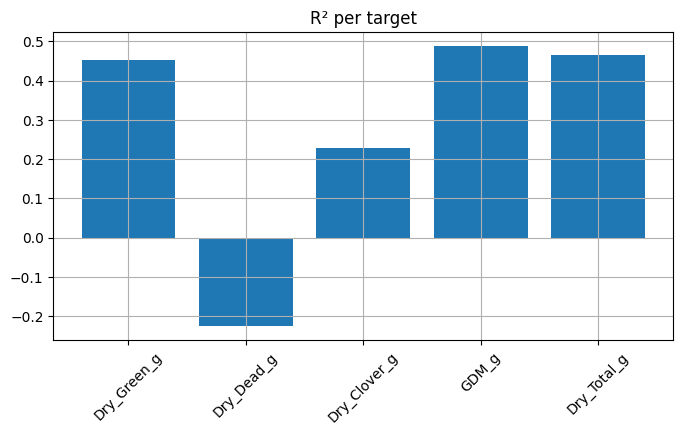

In [19]:
plt.figure(figsize=(8,4))
plt.bar(r2_per_label.keys(), r2_per_label.values())
plt.title("R² per target")
plt.xticks(rotation=45)
plt.grid()
plt.show()

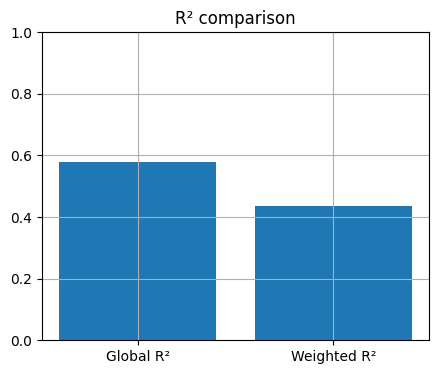

In [20]:
plt.figure(figsize=(5,4))
plt.bar(["Global R²", "Weighted R²"], [global_r2, weighted_r2_score])
plt.title("R² comparison")
plt.ylim(0,1)
plt.grid()
plt.show()

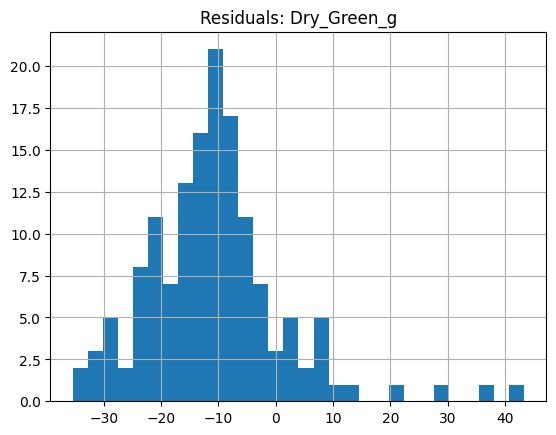

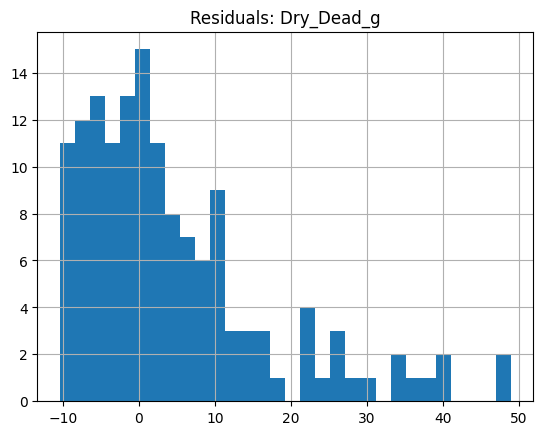

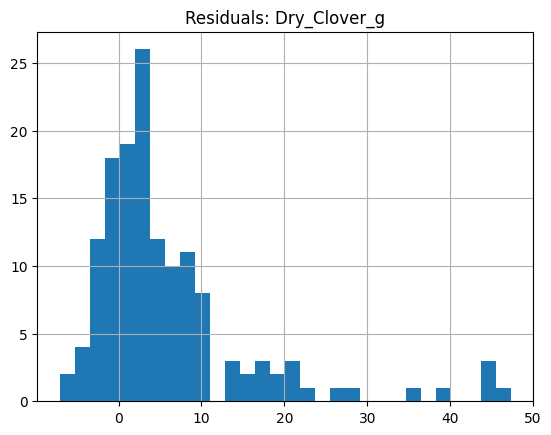

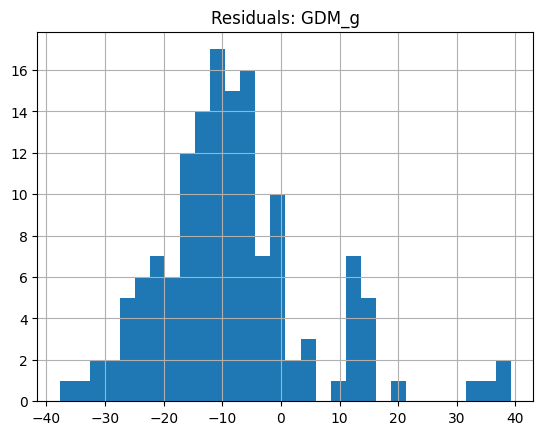

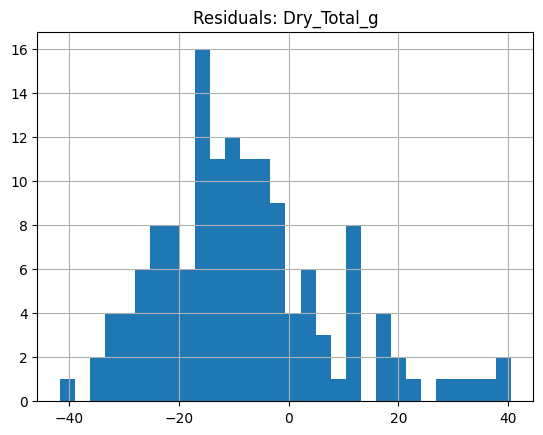

In [21]:
for name in TARGET_NAMES:
    sub = results_df[results_df["name"] == name]

    plt.figure()
    plt.hist(sub["residual"], bins=30)
    plt.title(f"Residuals: {name}")
    plt.grid()
    plt.show()

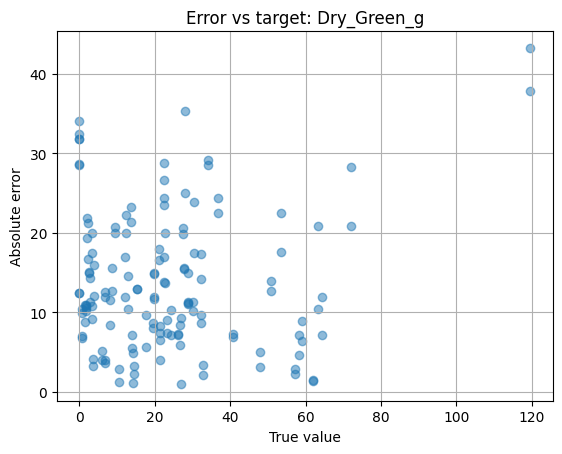

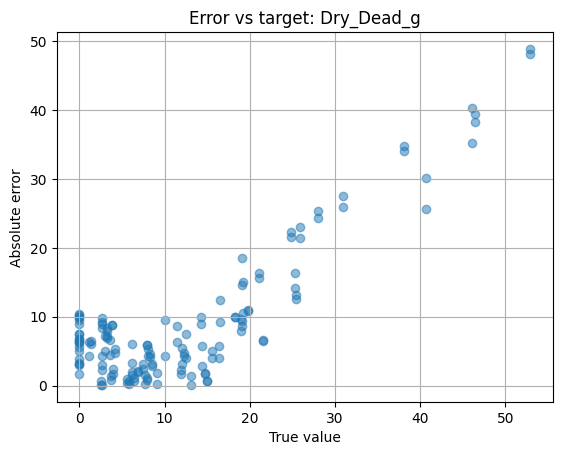

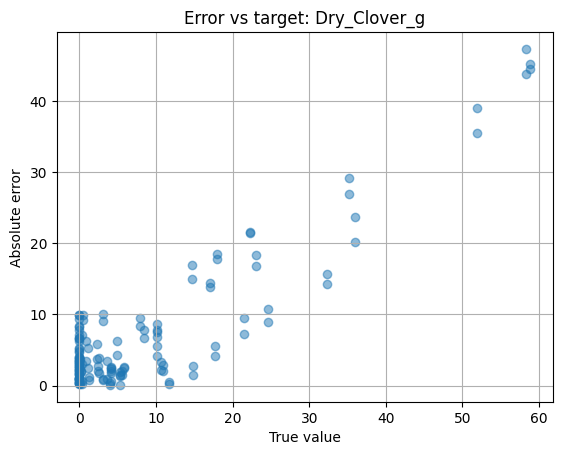

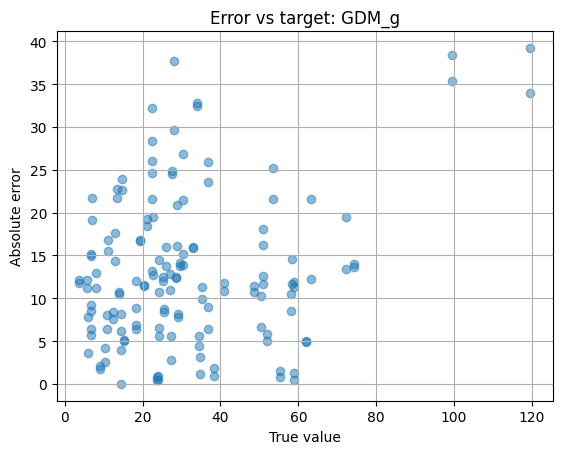

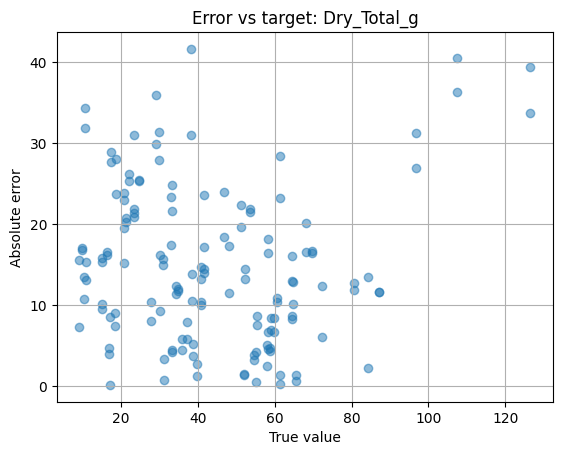

In [22]:
results_df["abs_error"] = np.abs(results_df["residual"])

for name in TARGET_NAMES:
    sub = results_df[results_df["name"] == name]

    plt.figure()
    plt.scatter(sub["target"], sub["abs_error"], alpha=0.5)
    plt.title(f"Error vs target: {name}")
    plt.xlabel("True value")
    plt.ylabel("Absolute error")
    plt.grid()
    plt.show()

In [23]:
# for downloading the final
results_df.to_csv("test_predictions.csv", index=False)
from google.colab import files
files.download("test_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>